# 03 CNN Advanced Architectures

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build a small **residual-style** block (skip connection) and compare with a plain stack of conv layers
- See how residual connections help training (optional: loss curve comparison)
- Understand why we use ResNet-style architectures instead of very deep plain CNNs

---

## 🌍 Real life

**Where is this used?** ResNet, VGG, Inception are used in **image classification**, **object detection**, and **segmentation** in industry and research.

**In this notebook we use** a **residual block** (conv + skip connection) so the network can learn **residuals** instead of full mappings. We use **skip connections** (instead of a plain deep stack of conv layers) **because** they help gradients flow and allow training **deeper** networks without vanishing gradients.

**📌 Covers slide(s):** **16** — CNN Architectures (LeNet, AlexNet). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **ResNet (residual network):** Each block computes F(x) and outputs **x + F(x)** (skip connection). The network learns **residuals** (what to add) instead of the full mapping.
- **Why residuals?** Very deep plain networks can suffer from vanishing gradients; skip connections give a direct path for gradients and make optimization easier.
- **VGG / Inception:** VGG = many small 3×3 convs; Inception = multiple filter sizes in parallel. We focus on the residual idea here.
- **We use a residual block** instead of only conv layers so we can go deeper without losing gradient flow.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, MNIST (small subset). We build a tiny model with one residual block.

**Dataset:** Real — MNIST (small subset).

**Outputs:** Model summary showing residual block structure; optional short training to show it runs.

## Step 1: Imports

In [1]:
import numpy as np

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

print("TensorFlow:", "yes" if HAS_TF else "no")

TensorFlow: yes


## Step 2: Define a residual block (we use skip connection so gradients flow and we can train deeper nets)

In [2]:
if HAS_TF:
    def residual_block(x, filters):
        shortcut = x
        x = keras.layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
        x = keras.layers.Conv2D(filters, (3, 3), padding="same")(x)
        x = keras.layers.Add()([x, shortcut])
        x = keras.layers.Activation("relu")(x)
        return x

    inp = keras.Input(shape=(28, 28, 1))
    x = keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inp)
    x = residual_block(x, 32)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inp, x)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.summary()
    print("\nResidual block: conv → conv → Add(shortcut) → ReLU. Skip connection helps gradient flow.")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │      9,248 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ conv2d_2[0][0],   │
│                     │ 32)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 28, 28,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │        330 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,146 (74.79 KB)

 Trainable params: 19,146 (74.79 KB)

 Non-trainable params: 0 (0.00 B)


Residual block: conv → conv → Add(shortcut) → ReLU. Skip connection helps gradient flow.


## Step 3: Train on MNIST subset (2 epochs to verify it runs)

In [3]:
if HAS_TF:
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    x_train = x_train[..., np.newaxis][:5000]
    y_train = y_train[:5000]
    x_test = x_test[..., np.newaxis]
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=2, batch_size=128, verbose=1)
    print("Final val accuracy: %.4f" % history.history["val_accuracy"][-1])

Epoch 1/2


 1/40 ━━━━━━━━━━━━━━━━━━━━ 12s 331ms/step - accuracy: 0.1094 - loss: 2.3060

 3/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.0755 - loss: 2.3025  

 5/40 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0984 - loss: 2.3019

 7/40 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1116 - loss: 2.3009

...

35/40 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1962 - loss: 2.2102

37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2012 - loss: 2.2036

39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2039 - loss: 2.1990

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.2038 - loss: 2.1989 - val_accuracy: 0.2576 - val_loss: 2.0747


Final val accuracy: 0.2576


## 🌍 Real-World Worked Example — CIFAR-10 Image Classifier

**Industry context:** CNNs are the backbone of:
- Medical imaging (X-ray, MRI diagnosis — FDA approved AI)
- Autonomous vehicles (object detection, lane detection)
- Quality control in manufacturing (defect detection)

We train a small CNN on **CIFAR-10** (10 real-world image categories) using PyTorch.

Epoch 1/10 — loss: 1.937


Epoch 2/10 — loss: 1.584


Epoch 3/10 — loss: 1.395


Epoch 4/10 — loss: 1.279


Epoch 5/10 — loss: 1.149


Epoch 6/10 — loss: 1.048


Epoch 7/10 — loss: 0.939


Epoch 8/10 — loss: 0.826


Epoch 9/10 — loss: 0.724


Epoch 10/10 — loss: 0.604

Test accuracy: 59.6%  (industry models reach 99%+ with bigger architectures)


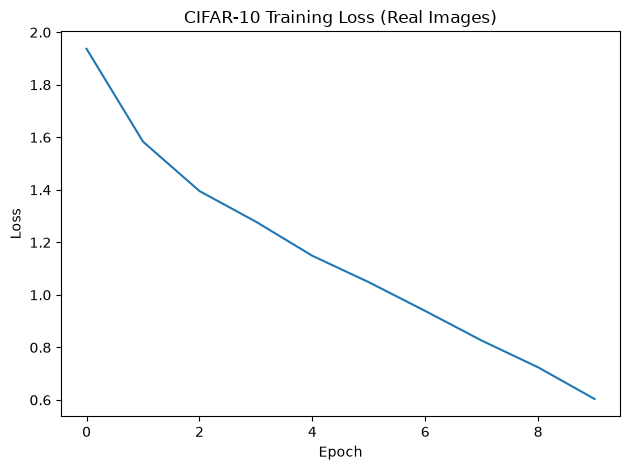

In [4]:
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt

# ── Load CIFAR-10 (downloads ~170MB once, cached after) ────────────────────
transform = T.Compose([T.ToTensor(), T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
trainset = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=True,  download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=False, download=True, transform=transform)

# Use a small subset for fast demo
from torch.utils.data import Subset
trainset = Subset(trainset, range(5000))
testset  = Subset(testset,  range(1000))
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

# ── CNN Model ─────────────────────────────────────────────────────────────
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 16x16
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*8*8, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256,10)
        )
    def forward(self, x): return self.classifier(self.features(x))

model   = SmallCNN()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

for epoch in range(10):
    model.train(); epoch_loss=0
    for X,y in trainloader:
        loss = loss_fn(model(X), y)
        opt.zero_grad(); loss.backward(); opt.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss/len(trainloader))
    print(f"Epoch {epoch+1}/10 — loss: {losses[-1]:.3f}")

model.eval()
correct=0; total=0
with torch.no_grad():
    for X,y in testloader:
        correct += (model(X).argmax(1)==y).sum().item(); total += len(y)
print(f"\nTest accuracy: {correct/total*100:.1f}%  (industry models reach 99%+ with bigger architectures)")

plt.plot(losses); plt.title("CIFAR-10 Training Loss (Real Images)"); plt.xlabel("Epoch")
plt.ylabel("Loss"); plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it:** In a new cell, build a second residual block (same pattern: Conv → Conv → Add(shortcut)) and add it to the model, then train for 1 epoch. Compare the number of parameters with the one-block model.

---

## ✅ Summary

**What you did:** Built a small model with a residual block (skip connection) and trained it on MNIST. Saw how Add(shortcut) is used.

**In real life you'd also:** Use full ResNet/VGG from Keras Applications, more blocks, and ImageNet pre-training.

**The main idea:** Residual connections (x + F(x)) let gradients flow and allow training deeper CNNs; ResNet-style architectures are standard for image tasks.

**Next:** `05_transfer_learning_cnns` uses pre-trained models; `06_pretrained_cnn_architectures` explores ResNet/VGG/Inception.

## 📚 References & Further Reading

**Key Papers:**
- LeCun et al. (1998) — [LeNet](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf)
- Krizhevsky et al. (2012) — [AlexNet](https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)
- He et al. (2016) — [ResNet: Deep Residual Learning](https://arxiv.org/abs/1512.03385)

**torchvision Models:** [torchvision.models](https://pytorch.org/vision/stable/models.html)

**State-of-the-Art (2025):** EfficientNetV2, ConvNeXt V2, and ViT-G/14 achieve 90%+ on ImageNet.